## Section 1.4: Sample differences between scanners and sites

**Modelling a single IDP**

Now we have established that image level differences will propogate into even the most simple derived metrics, such as volume measurements, we will look at how this may affect pooled, using *simulated* tabular multi-site datasets.

In the most simple modelling approach, an individual measurement for one individual (for example, hippocampal volume) for participant i at site j can be expressed as a simple linear model of the form below:

$ y_{ij} = \alpha_j + \epsilon_{ij}$

Where:

- $y_{ij}$ is the observed measurement

- $\alpha_j$ is the average value at site $j$

- $\epsilon_{ij}$ represents subject-level variation and noise

This assumes that a single measurement, for example the volume, is just a linear combination of the mean volume of that ROI, plus some subject specific effect $\epsilon$

**Incorporating Biological Covariates**

However, we know that volumes will be affected by many other variables, such as age, sex, height, weight or disease. As such, a better simulated model will also include terms for these measures, and potentially interactions between them (such as age $\times$ sex).

The most simple model, assuming no interactions, is then:

$ y_{ij} = \alpha_j + X_i \beta_j + \epsilon_{ij}$

Have a look at what this looks like below; Here we simulate three sites, all drawn from the same normal distribution, and then choose site specific population characteristics. These will share the same fixed effects, but different distributions among sites.

Have a go at changing these characteristics below in the GUI and look at the resulting histograms.

**As you work through the simulations, consider:**

- Which variables are true biological effects?
- Which variables might act as confounds?
- What happens if site and biological variables become correlated?



In [ ]:
from block1_utils.SimulateDataBlock1 import make_simulator_input_gui
import matplotlib.pyplot as plt 
import pathlib
_ = make_simulator_input_gui()

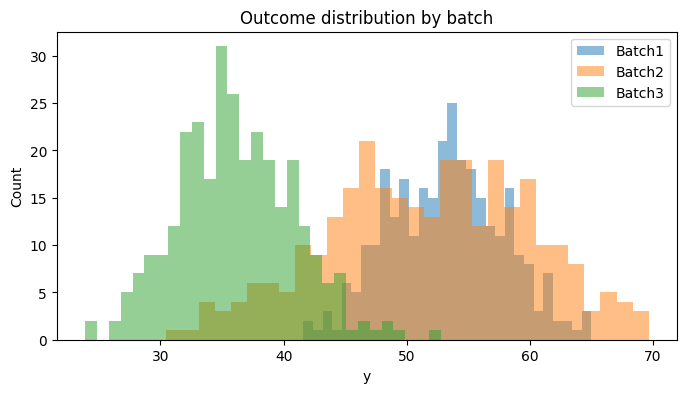

In [6]:
from block1_utils.SimulateDataBlock1 import simulate_batched_data

data =[]
params = make_simulator_input_gui.last_result
data = params["data"]
batch = params["batch"]
covariate_specs = params["covariate_specs"]
betas = params["betas"]
batch_params = params["batch_params"]

df = simulate_batched_data(
    data=data,
    batch=batch,
    covariate_specs=covariate_specs,
    betas=betas,
    noise_sd=1.0,
    seed=123,
)
df.head()

plt.figure(figsize=(8, 4))
for b in df["batch"].unique():
    plt.hist(df.loc[df["batch"] == b, "y"], bins=30, alpha=0.5, label=b)
plt.legend()
plt.title("Outcome distribution by batch")
plt.xlabel("y")
plt.ylabel("Count")
plt.show()

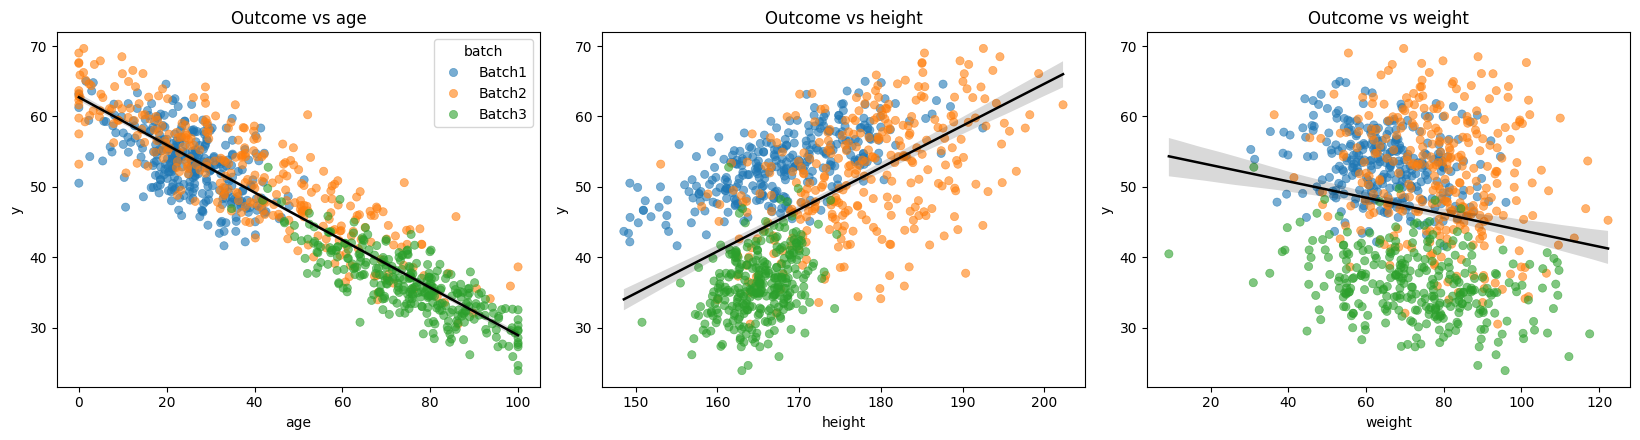

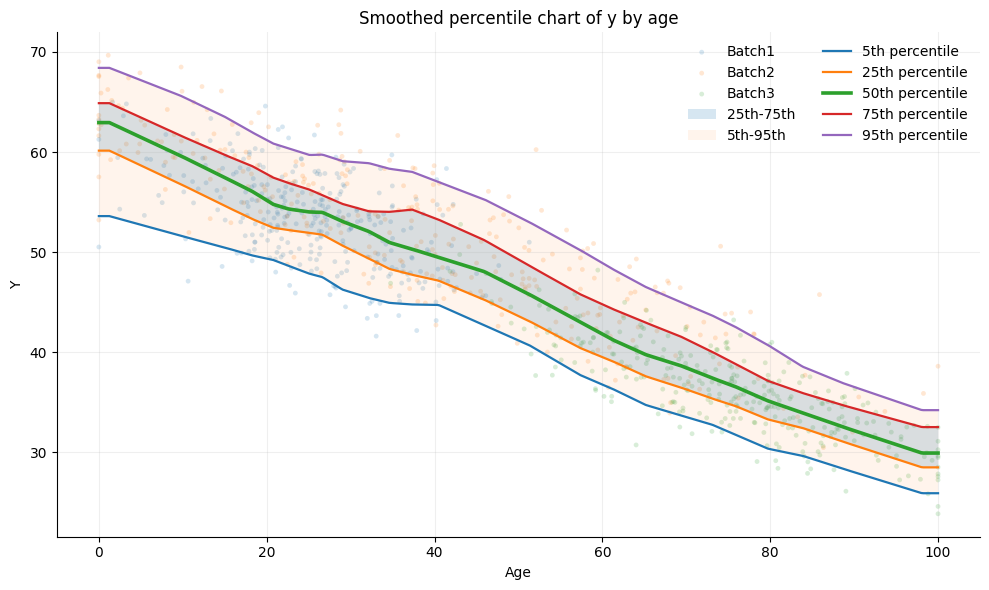

In [7]:
from block1_utils.PlottingBlock1 import plot_charts, plot_age_percentile_chart

fig = plot_charts(df, ["age", "height", "weight"], batch_col="batch", outcome_col="y")

# Also show the age nomogram:

fig, ax = plot_age_percentile_chart(
    df,
    age_col="age",
    value_col="y",
    batch_col="batch",
    n_bins=25,
    smooth_frac=0.25,
    show_points=True,
    show_batch_coloring=True,
)

plt.show()

## Section 1.5: Non-biological site differences

So far, we have simulated biological variation without major scanner-related distortions. We will now introduce explicit batch effects into the dataset.

Batch effects can alter both:

- The mean of a measurement distribution

- The variance of the measurement distribution

A commonly used harmonisation framework (such as ComBat) models the data using an expression similar to:

$ y_{ij} = \alpha_j + X_i \beta_j +  X_i \beta_{batch} + \delta_{batch,i} \times \epsilon_{ij}$

- $\alpha_j$ represents the baseline mean

- $X_i \beta_j$ captures biological covariate effects

- $X_i \beta_{batch}$ represents additive batch effects ($\gamma_{b,j}$ is often also used)

- $\delta_{batch}$ represents multiplicative variance effects

- $\epsilon_{ij}$ is residual error


Batch effects can produce misleading conclusions if not properly accounted for.

For example: A disease group may appear different simply because most patients were scanned at one site or scanner differences may mask genuine biological relationships.

As you explore the simulations, think carefully about:

- Which effects are biological?

- Which are scanner-related?

- How difficult would it be to separate these effects in a real study?


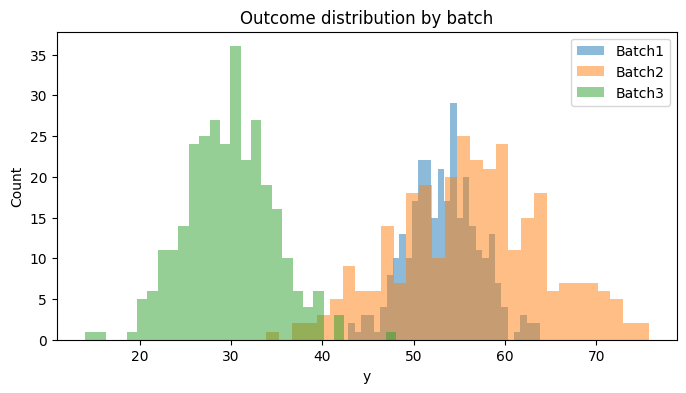

In [10]:
from block1_utils.SimulateDataBlock1 import simulate_batched_data

# Add some batch effects to the data and see how they impact the distribution of the outcome variable. 
# We will simulate data with 3 batches, each with different covariate distributions and batch effects.
batch_params = {
    "Batch1": {"add_mean": 0.00, "add_sd": 0.05, "multi_mean": 1.00, "multi_shape": 25.0},
    "Batch2": {"add_mean": 5, "add_sd": 0.08, "multi_mean": 1.5, "multi_shape": 18.0},
    "Batch3": {"add_mean": -7, "add_sd": 0.06, "multi_mean": 0.8, "multi_shape": 30.0},
}
# Recreate the data this time with the batch effects:
df2 = simulate_batched_data(
    data=data,
    batch=batch,
    covariate_specs=covariate_specs,
    betas=betas,
    batch_params=batch_params,
    noise_sd=1.0,
    relative_batch_effects=True,
    seed=42,
)

plt.figure(figsize=(8, 4))
for b in df2["batch"].unique():
    plt.hist(df2.loc[df2["batch"] == b, "y"], bins=30, alpha=0.5, label=b)
plt.legend()
plt.title("Outcome distribution by batch")
plt.xlabel("y")
plt.ylabel("Count")
plt.show()


After introducing batch effects, the relationships between imaging measurements and explanatory variables become much harder to interpret.

In many cases:

- Correlations weaken

- Variability increases

- Site-specific clusters emerge

- Biological trends become obscured

This is one of the central challenges of multi-site neuroimaging. Even relatively small scanner effects can distort normative trajectories, bias machine learning models, reduce reproducibility and produce spurious findings.

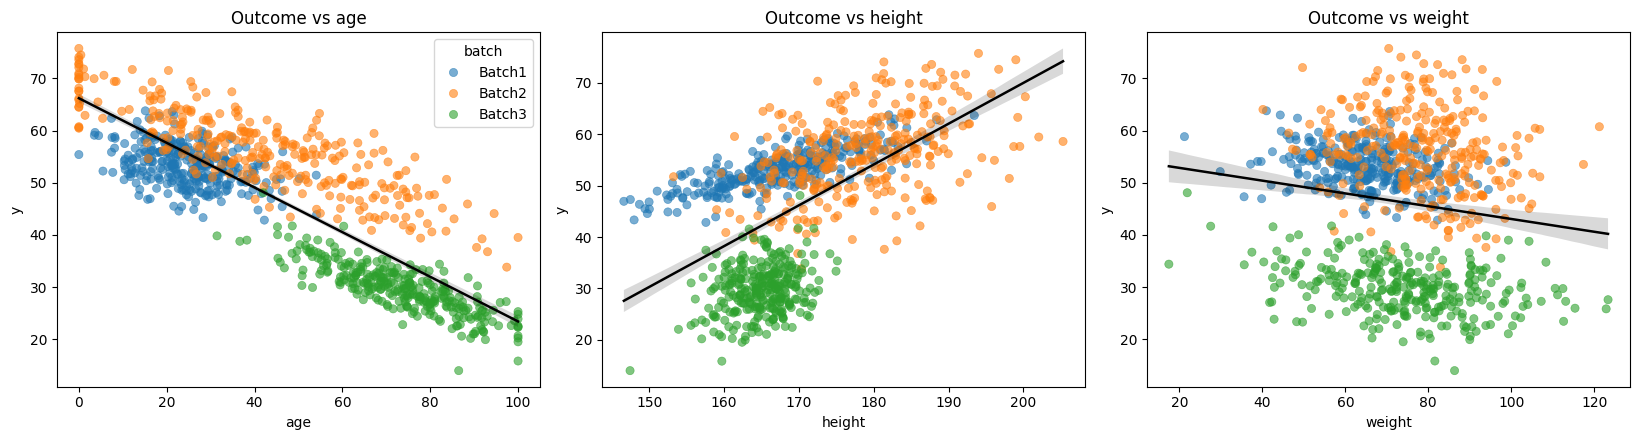

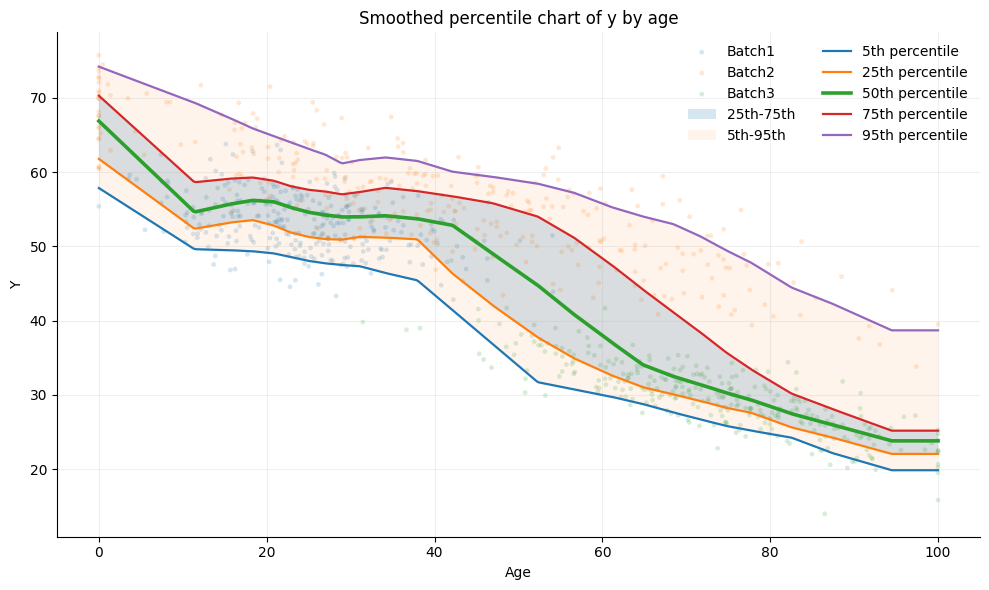

In [11]:
from block1_utils.PlottingBlock1 import plot_charts
fig = plot_charts(df2, ["age", "height", "weight"], batch_col="batch", outcome_col="y")

fig, ax = plot_age_percentile_chart(
    df2,
    age_col="age",
    value_col="y",
    batch_col="batch",
    n_bins=25,
    smooth_frac=0.25,
    show_points=True,
    show_batch_coloring=True,
)

## Summary:

*In this tutorial, we explored how scanner and site effects can influence neuroimaging data at multiple levels, from raw image appearance to derived quantitative measurements and downstream statistical analyses. While multi-site studies are essential for building large and representative datasets, they also introduce technical variability that can obscure true biological effects if not carefully accounted for. Understanding, identifying, and mitigating these sources of variation is therefore a critical part of modern neuroimaging research. As imaging datasets continue to grow in scale and complexity, robust harmonisation strategies and thoughtful study design will remain essential for ensuring reliable, reproducible, and biologically meaningful results.*


# Analysing batch effects in MRI data with DiagnoseHarmonise (DHARM)


![QR code to the DHARM webpage](DHARM.png "DHARM")


## Why this matters

In multi-site MRI studies, scanner and site effects can influence neuroimaging data at several levels: raw image appearance, derived quantitative measurements, and downstream statistical analyses. Multi-site datasets are essential for building larger and more representative studies, but they also introduce technical variation that can obscure true biological effects if it is not properly addressed.

A good harmonisation workflow should therefore do more than apply a correction method. It should first **diagnose** the batch effects that are present, then assess whether harmonisation reduced those effects while preserving meaningful biological signal. Comparing the data **before and after harmonisation** is one of the most useful ways to check that the method has worked as intended.

## DiagnoseHarmonise (DHARM)

DiagnoseHarmonise (DHARM) is a Python library for the streamlined application and assessment of harmonisation algorithms at the summary-measure level. It provides structured diagnostic reports to help users evaluate batch effects in MRI data and judge whether harmonisation was needed, and whether it was successful. The project is available on GitHub, and the documentation describes a command-line workflow as well as a desktop GUI launcher for cross-sectional analyses.

You can install or explore the library via:

- **PyPI** pip install DiagnoseHarmonise
- **GitHub**

## Tools for analysing batch effects presented at OHBM 2026

- **Poster 2005**: An open-source tool for the analysis of batch differences and harmonisation efficacy for MRI data
- **Poster 2004**: A Tool for Transparent and Standardized Assessment of Multisite Harmonization in Neuroimaging

## Take-home message

As imaging datasets continue to grow in scale and complexity, robust harmonisation strategies and thoughtful study design remain essential for reliable, reproducible, and biologically meaningful results.

# Citations:
[1] Warrington, S., Torchi, A., Mougin, O. et al. A multi-site, multi-modal travelling-heads resource for brain MRI harmonisation. Sci Data 12, 609 (2025). https://doi.org/10.1038/s41597-025-04822-2

[2] M.W. Woolrich, S. Jbabdi, B. Patenaude, M. Chappell, S. Makni, T. Behrens, C. Beckmann, M. Jenkinson, S.M. Smith. Bayesian analysis of neuroimaging data in FSL. NeuroImage, 45:S173-86, 2009

[3] S.M. Smith, M. Jenkinson, M.W. Woolrich, C.F. Beckmann, T.E.J. Behrens, H. Johansen-Berg, P.R. Bannister, M. De Luca, I. Drobnjak, D.E. Flitney, R. Niazy, J. Saunders, J. Vickers, Y. Zhang, N. De Stefano, J.M. Brady, and P.M. Matthews. Advances in functional and structural MR image analysis and implementation as FSL. NeuroImage, 23(S1):208-19, 2004

[4] M. Jenkinson, C.F. Beckmann, T.E. Behrens, M.W. Woolrich, S.M. Smith. FSL. NeuroImage, 62:782-90, 2012

[5] Bethlehem, R.A.I., Seidlitz, J., White, S.R. et al. Brain charts for the human lifespan. Nature 604, 525–533 (2022). https://doi.org/10.1038/s41586-022-04554-y

